In [1]:
import numpy as np
from qiskit.quantum_info import DensityMatrix, state_fidelity
import matplotlib.pyplot as plt

In [2]:
hadamard = [[1/np.sqrt(2),1/np.sqrt(2)], [1/np.sqrt(2), -1/np.sqrt(2)]]
identity = [[1,0], [0,1]]

theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
ry_theta = [[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]]

cz = [[1,0,0,0], [0,1,0,0], [0,0,1,0], [0,0,0,-1]]

In [3]:
def state_prep(matrix):
    matrix = np.array(matrix)
    ry_ry_ry = np.kron(ry_theta, np.kron(ry_theta, ry_theta))
    answer = ry_ry_ry @ matrix @ ry_ry_ry.conj().T
    return answer / np.trace(answer)

def first_layer(matrix):
    matrix = np.array(matrix)
    cz_h = np.kron(cz, hadamard)
    answer = cz_h @ matrix @ cz_h.conj().T
    return answer / np.trace(answer)

def second_layer(matrix):
    matrix = np.array(matrix)
    i_cz = np.kron(identity, cz)
    answer = i_cz @ matrix @ i_cz.conj().T
    return answer / np.trace(answer)

def third_layer(matrix):
    matrix = np.array(matrix)
    h_h_i = np.kron(hadamard, np.kron(hadamard, identity))
    answer = h_h_i @ matrix @ h_h_i.conj().T 
    return answer / np.trace(answer)

def meas(matrix):
    matrix = np.array(matrix)
    two_qubit_projector = [[1,0,0,0], [0,0,0,0], [0,0,0,0], [0,0,0,0]]
    projector = np.kron(two_qubit_projector, identity)
    answer = projector @ matrix @ projector.conj().T
    return answer / np.trace(answer)

def noisy_state_prep1(matrix, error_prob):
    matrix = np.array(matrix)
    i_ry_i = np.kron(identity, np.kron(ry_theta, identity))
    new_dm = i_ry_i @ matrix @ i_ry_i.conj().T 
    mixed = np.kron(np.matmul([[1], [0]], [[1,0]]), np.kron(np.asarray(identity)/2, np.matmul([[1], [0]], [[1,0]])))
    
    answer = (1-error_prob)*new_dm + error_prob * mixed
    
    return answer / np.trace(answer)

def noisy_state_prep2(matrix, error_prob):
    matrix = np.array(matrix)
    ry_i_i = np.kron(ry_theta, np.kron(identity, identity))
    new_dm = ry_i_i @ matrix @ ry_i_i.conj().T 
    traced_dm = new_dm[0:4, 0:4] + new_dm[4:8, 4:8]
    answer = (1-error_prob)*new_dm + error_prob * np.kron(np.asarray(identity)/2, traced_dm)
    
    return answer / np.trace(answer)


def noisy_state_prep3(matrix, error_prob):
    matrix = np.array(matrix)
    i_i_ry = np.kron(identity, np.kron(identity, ry_theta))
    new_dm = i_i_ry @ matrix @ i_i_ry.conj().T 
    
    traced_dm = []
    for i in range(0, 7, 2):
        temp = []
        for j in range(0, 7, 2):
            temp.append(new_dm[i,j] + new_dm[i+1,j+1])
        traced_dm.append(temp)
    traced_dm = np.array(traced_dm)
    
    answer = (1-error_prob)*new_dm + error_prob * np.kron(traced_dm, np.asarray(identity)/2)
    return answer / np.trace(answer)


def noisy_state_prep(matrix, error_prob):
    output = noisy_state_prep1(matrix, error_prob)
    output = noisy_state_prep2(output, error_prob)
    output = noisy_state_prep3(output, error_prob)
    
    return output

Ideal circuits

In [4]:
one_q_zero_dm = np.matmul([[1], [0]], [[1,0]])
ideal = np.kron(one_q_zero_dm, np.kron(one_q_zero_dm, one_q_zero_dm))

i_i_ry = np.kron(identity, np.kron(identity, ry_theta))
ideal = i_i_ry @ ideal @ i_i_ry.conj().T 

ideal /= np.trace(ideal)

In [5]:
ideal_input = one_q_zero_dm
ideal_input = np.asarray(ry_theta) @ ideal_input @ np.asarray(ry_theta).conj().T
ideal_input /= np.trace(ideal_input)

noisy circuits

In [6]:
error_prob = 0.3

one_q_zero_dm = np.matmul([[1], [0]], [[1,0]])
init = np.kron(one_q_zero_dm, np.kron(one_q_zero_dm, one_q_zero_dm))
output = noisy_state_prep(init, error_prob)

output = first_layer(output)
output = second_layer(output)
output = third_layer(output)
final = meas(output)

In [7]:
input = one_q_zero_dm
input = np.asarray(ry_theta) @ input @ np.asarray(ry_theta).conj().T
input = (1-error_prob)*input + error_prob *np.eye(2)/2
input /= np.trace(input)

fidelity comparisons

In [8]:
dm_final = DensityMatrix(final)
dm_ideal = DensityMatrix(ideal)
dm_input = DensityMatrix(input)
dm_ideal_input = DensityMatrix(ideal_input)

output_fidelity = state_fidelity(dm_final, dm_ideal)
input_fidelity = state_fidelity(dm_input, dm_ideal_input)
print(f"For Depolarizing Error Probability = {error_prob}")
print(f"Output Fidelity = {output_fidelity}")
print(f"Input Fidelity = {input_fidelity}")

For Depolarizing Error Probability = 0.3
Output Fidelity = 0.8514144407732123
Input Fidelity = 0.8500000025862307


Graphing

In [12]:
dm_ideal = DensityMatrix(ideal)
dm_ideal_input = DensityMatrix(ideal_input)

In [22]:
depol_error_list = np.linspace(0.01, 0.4, 1_000)
output_infidelity_list = []
input_infidelity_list = []

for e in depol_error_list:
    one_q_zero_dm = np.matmul([[1], [0]], [[1,0]])
    init = np.kron(one_q_zero_dm, np.kron(one_q_zero_dm, one_q_zero_dm))
    output = noisy_state_prep(init, e)

    output = first_layer(output)
    output = second_layer(output)
    output = third_layer(output)
    final = meas(output)
    dm_final = DensityMatrix(final)
    
    
    input = one_q_zero_dm
    input = np.asarray(ry_theta) @ input @ np.asarray(ry_theta).conj().T
    input = (1-e)*input + e *np.eye(2)/2
    input /= np.trace(input)
    dm_input = DensityMatrix(input)
    
    output_infidelity_list.append(1-state_fidelity(dm_final, dm_ideal)) 
    input_infidelity_list.append(1-state_fidelity(dm_input, dm_ideal_input))

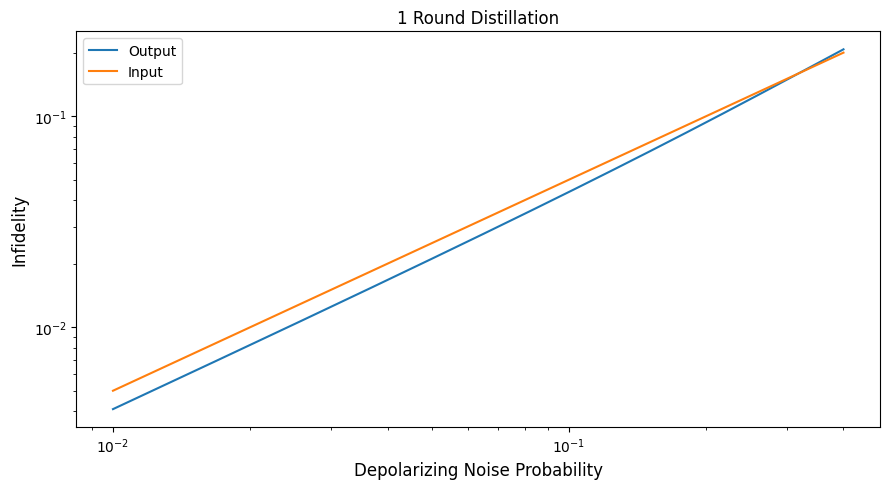

In [23]:
plt.figure(figsize=(9, 5))
plt.plot(depol_error_list, output_infidelity_list, label='Output')
plt.plot(depol_error_list, input_infidelity_list, label='Input')
plt.xlabel("Depolarizing Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.title("1 Round Distillation")
plt.tight_layout()
plt.legend()
plt.show()

Approximating the threshold noise probability and infidelity

In [24]:
thr = 0
for i in range(len(depol_error_list)):
    if (output_infidelity_list[i] >= input_infidelity_list[i]):
        thr = depol_error_list[i]
        print(thr)
        break

0.3187987987987988


In [25]:
def error_to_inf(error_list, num_qubits):
    inf_list = []
    dim = 2**num_qubits
    for error in error_list:
        inf_list.append(error * (dim - 1)/dim)
        
    return inf_list

In [26]:
print(f"Infidelity Threshold = {error_to_inf([thr], 1)[0]}")

Infidelity Threshold = 0.1593993993993994
